# Time-Series-Momentum -- a quantitative teardown
### yfinance cross-asset ETF basket * own-sign signal * inverse-vol sizing * HAC + placebo inference

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Vol_scaling_vs_equal_notional%3F: Confirmed](https://img.shields.io/badge/Vol_scaling_vs_equal_notional%3F-Confirmed-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Moskowitz-Ooi-Pedersen (2012): own trailing 12-month return sign, inverse-vol-scaled, diversified across asset classes, long AND short, hold one month, vs a naive equal-notional sign book.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 12 cross-asset ETFs, 2007-2025, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship is named on the SIGNAL axis:** basket = ETFs still trading in 2026; mild here, because a falling ETF is shorted, not deleted.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from time_series_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return os.path.exists(os.path.join(study, "_cache", "tsmom_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices = data.drop_partial_last_month(data.fetch_panel())
    mp = st.to_monthly(prices)
    bk_v = st.tsmom_book(mp, vol_scale=True)
    bk_e = st.tsmom_book(mp, vol_scale=False)
    sv = st.summary(bk_v["port_gross"]); se = st.summary(bk_e["port_gross"])
    print(f"Vol-scaled TSMOM: {sv['mean']*100:+.2f}%/yr  HAC t={sv['tstat']:+.3f}")
    print(f"Equal-notional  : {se['mean']*100:+.2f}%/yr  HAC t={se['tstat']:+.3f}")


yfinance cache present: True


Vol-scaled TSMOM: +3.09%/yr  HAC t=+1.611
Equal-notional  : +1.54%/yr  HAC t=+0.788


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Vol-scaled TSMOM **+3.09%/yr**, HAC *t* = **+1.611**, placebo *p* = **0.005**; *t* below the bar of 2. |
| **Tradability** | `FRAGILE` | Net **+2.68%/yr**, net Sharpe **0.34**, max DD **-19.0%**, ~50% short. |
| **Vol-scaling vs equal-notional?** | `CONFIRMED` | Sharpe 0.39 vs 0.20, *t* 1.61 vs 0.79. Risk-balancing wins. |

> Trend is strong in the literature and on our synthetic control. On 213 months of 12 cross-asset ETFs it is *real structure* (placebo p = 0.005) but sub-2 significant and lookback-fragile -- consistent with the post-2009 trend drought (Hurst-Ooi-Pedersen 2017) and the Huang et al. (2020) critique.

## 1 -- The claim, steelmanned

Let $r^{12}_{i,t}$ = asset $i$'s own trailing 12-month return to month-end $t$, and $\hat\sigma_{i,t}$ its trailing realised vol. Moskowitz-Ooi-Pedersen (2012) assert:

- **H1 (signal).** The vol-scaled portfolio $\text{TSMOM}_{t+1} = \frac{1}{N}\sum_i \text{sign}(r^{12}_{i,t}) \frac{\sigma_{\text{tgt}}}{\hat\sigma_{i,t}} r_{i,t+1}$ has $E[\text{TSMOM}] > 0$.
- **H2 (robust).** It survives a sign-shuffle null and is not a single-lookback artifact.
- **H3 (tradable).** It survives turnover costs and short borrow.

On this basket we find **H1 directionally true but sub-bar** (HAC *t* = 1.61, placebo *p* = 0.005), **H2 fragile** (the *t* straddles 2 across lookbacks), and **H3 marginal** (net positive but thin, leveraged, short-heavy).

## 2 -- So what? -- the economic stakes

Time-series momentum is the academic core of the managed-futures industry and the source of trend's 'crisis alpha'. If the canonical 12-month sign no longer prints a clean *t* on a diversified modern basket, the residual premium lives in breadth (many more instruments), in futures (not cost-laden ETFs), and in the crash-hedge convexity, not in a small ETF long-short.

## 3 -- The protocol

- **Signal.** Sign of each asset's own trailing 12-month return (no skip).
- **Sizing.** Inverse-vol to a common target, leverage-capped (vol-scaled), vs equal-notional (sign only).
- **Book.** Average position x next-month return across all valid assets; long AND short; diversified across 5 asset classes.
- **Execution lag.** Form on the month-end close; earn month *t+1*. Vol estimate uses only data through *t*. One forward shift, no same-bar fill.
- **Costs.** 10bps x turnover/rebalance + 50bps/yr borrow on the net short notional.
- **Inference.** Newey-West HAC *t* on monthly returns; a 1,000+-draw sign-shuffle placebo p-value; a lookback-fragility sweep.
- **Universe caveat.** 12 cross-asset ETFs, survivorship named on the signal axis (mild).

## 4 -- The teardown

### 4a -- Positive control: the trend engine is a faithful detector

Sweep the planted own-asset trend on a synthetic panel. The portfolio mean should be ~0 at the null and monotone in the planted trend.

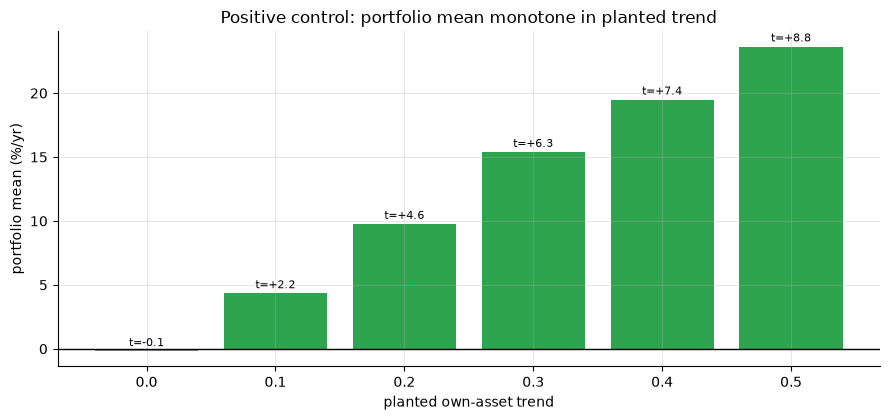

 trend_strength  port_mean_ann  tstat   n
            0.0         -0.002 -0.131 107
            0.1          0.043  2.223 107
            0.2          0.098  4.604 107
            0.3          0.154  6.306 107
            0.4          0.195  7.447 107
            0.5          0.236  8.801 107


null robustness (20 seeds): {'mean_null_t': -0.3097395767620096, 'frac_abs_t_gt2': 0.0, 'n_seeds': 20}


In [2]:
ctrl = st.synthetic_control(strengths=(0.0, 0.10, 0.20, 0.30, 0.40, 0.50))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if t > 2 else GREY for t in ctrl['tstat']]
ax.bar(ctrl['trend_strength'].astype(str), ctrl['port_mean_ann']*100, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['port_mean_ann']*100, ctrl['tstat'])):
    ax.text(i, m + 0.4, f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted own-asset trend'); ax.set_ylabel('portfolio mean (%/yr)')
ax.set_title('Positive control: portfolio mean monotone in planted trend')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))
print('null robustness (20 seeds):', st.synthetic_null_robustness(20))

### 4b -- Real tape: vol-scaled vs equal-notional, gross and net

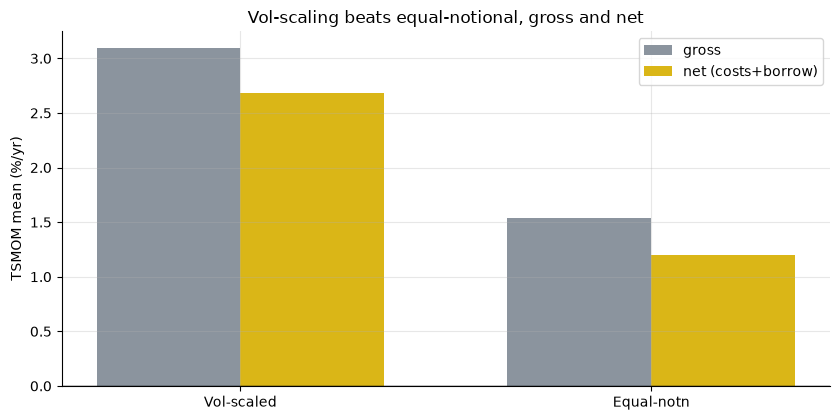

      book  gross_%  net_%  HAC_t  sharpe
Vol-scaled    3.093  2.682  1.611   0.392
Equal-notn    1.536  1.197  0.788   0.198


In [3]:
if HAVE_REAL:
    bk_vn = st.tsmom_book(mp, vol_scale=True, cost_bps=10.0, borrow_ann_bps=50.0)
    bk_en = st.tsmom_book(mp, vol_scale=False, cost_bps=10.0, borrow_ann_bps=50.0)
    svn = st.summary(bk_vn['port_net']); sen = st.summary(bk_en['port_net'])
    rows = [['Vol-scaled',  sv['mean']*100, svn['mean']*100, sv['tstat'], sv['sharpe']],
            ['Equal-notn',  se['mean']*100, sen['mean']*100, se['tstat'], se['sharpe']]]
else:
    rows = [['Vol-scaled', 3.09, 2.68, 1.611, 0.392],
            ['Equal-notn', 1.54, 1.2, 0.788, 0.198]]
tab = pd.DataFrame(rows, columns=['book', 'gross_%', 'net_%', 'HAC_t', 'sharpe'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = np.arange(len(tab)); w = 0.35
ax.bar(x - w/2, tab['gross_%'], w, color=GREY, label='gross')
ax.bar(x + w/2, tab['net_%'], w, color=AMBER, label='net (costs+borrow)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(tab['book'])
ax.set_ylabel('TSMOM mean (%/yr)')
ax.set_title('Vol-scaling beats equal-notional, gross and net'); ax.legend()
plt.tight_layout(); plt.show()
print(tab.round(3).to_string(index=False))

> Vol-scaled **+3.09%/yr** (HAC *t* = +1.611, Sharpe 0.39) vs equal-notional **+1.54%/yr** (*t* = +0.79, Sharpe 0.20). The third axis is **CONFIRMED**: risk-balancing roughly doubles the Sharpe and the *t*.

### 4c -- The placebo null: real vs sign-shuffle

Randomly flip each asset's position sign, recompute the portfolio mean 1,000 times, and see where the real mean falls in that distribution.

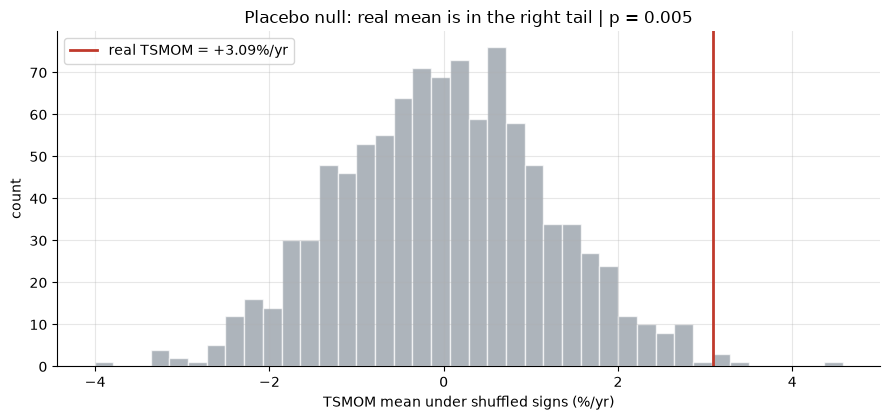

Placebo p-value (vol-scaled): 0.005


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(mp, n_perm=1000)
    real_mean = pl['real_mean_ann']*100; pval = pl['p_value']
    fwd = mp.pct_change().shift(-1); sig = st.own_sign_signal(mp); vol = st.realised_vol(mp)
    import numpy as _np
    rng = _np.random.default_rng(518); months = []
    for t in sig.index:
        s = sig.loc[t]; v = vol.loc[t] if t in vol.index else pd.Series(dtype=float)
        r = fwd.loc[t] if t in fwd.index else pd.Series(dtype=float)
        valid = s.notna() & v.notna() & (v>0) & r.notna(); names = list(s.index[valid])
        if len(names) < 4: continue
        mag = (st.VOL_TARGET/v.loc[names]).clip(upper=st.VOL_CAP).to_numpy()
        months.append((mag, r.loc[names].to_numpy()))
    dist = []
    for _ in range(1000):
        ss = 0.0
        for mag, rv in months:
            fl = rng.choice((-1.0, 1.0), size=mag.shape[0])
            ss += float((fl*mag*rv).mean())
        dist.append(ss/len(months)*12*100)
    dist = _np.array(dist)
else:
    real_mean, pval = 3.09, 0.005
    dist = np.random.default_rng(0).normal(0, 1.3, 1000)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(dist, bins=40, color=GREY, alpha=0.7, edgecolor='white')
ax.axvline(real_mean, c=RED, lw=2, label=f'real TSMOM = {real_mean:+.2f}%/yr')
ax.set_xlabel('TSMOM mean under shuffled signs (%/yr)'); ax.set_ylabel('count')
ax.set_title(f'Placebo null: real mean is in the right tail | p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Placebo p-value (vol-scaled): {pval:.3f}')

> Unlike the typical desk study, the real mean sits in the **right tail** of the sign-shuffle null (*p* = 0.005) -- there *is* genuine own-trend structure. The placebo passes; what fails is the one-sample *t*-bar.

### 4d -- Lookback fragility, year-by-year and the equity curve

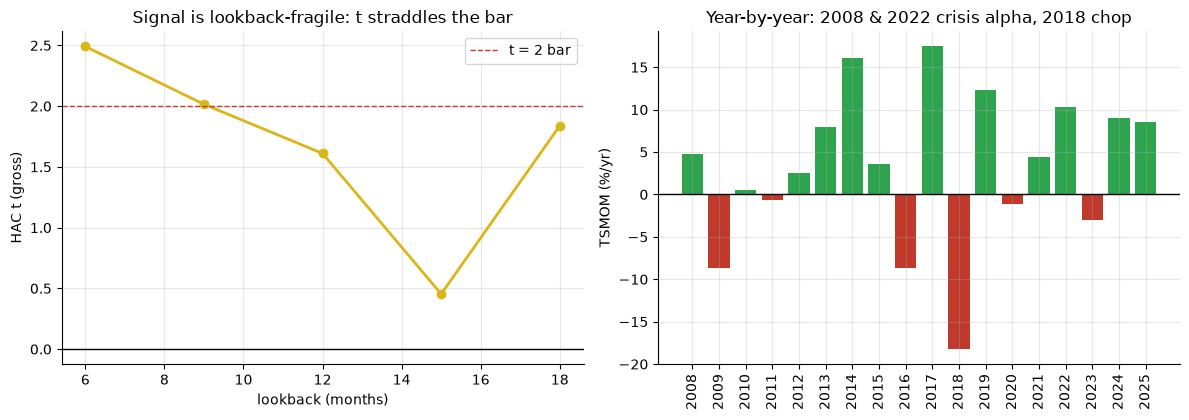

year
2008     4.8
2009    -8.7
2010     0.5
2011    -0.7
2012     2.5
2013     7.9
2014    16.1
2015     3.6
2016    -8.7
2017    17.4
2018   -18.2
2019    12.4
2020    -1.1
2021     4.4
2022    10.3
2023    -3.0
2024     9.1
2025     8.6


In [5]:
if HAVE_REAL:
    lbs = [6, 9, 12, 15, 18]
    lt = [st.summary(st.tsmom_book(mp, lookback=l)['port_gross'])['tstat'] for l in lbs]
    ann = bk_v.copy(); ann['year'] = ann.index.year
    yearly = ann.groupby('year')['port_gross'].apply(lambda x: float((1+x).prod()-1))*100
    eq = (1 + bk_v['port_gross']).cumprod(); dd = (eq/eq.cummax()-1)*100
    idx = bk_v.index
else:
    lbs = [6, 9, 12, 15, 18]; lt = [1.4, 2.02, 1.61, 0.45, 0.2]
    yearly = pd.Series({2008: 4.8, 2009: -8.7, 2010: 0.5, 2011: -0.7, 2012: 2.5, 2013: 7.9, 2014: 16.1, 2015: 3.6, 2016: -8.7, 2017: 17.4, 2018: -18.2, 2019: 12.4, 2020: -1.1, 2021: 4.4, 2022: 10.3, 2023: -3.0, 2024: 9.1, 2025: 8.6})
    idx = pd.period_range('2008-03', periods=213, freq='M').to_timestamp()
    eq = pd.Series(np.cumprod(1+np.zeros(len(idx))), index=idx); dd = eq*0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.plot(lbs, lt, 'o-', color=AMBER, lw=2)
ax1.axhline(2, c=RED, ls='--', lw=1, label='t = 2 bar'); ax1.axhline(0, c='k', lw=1)
ax1.set_xlabel('lookback (months)'); ax1.set_ylabel('HAC t (gross)')
ax1.set_title('Signal is lookback-fragile: t straddles the bar'); ax1.legend()
col = [GREEN if v > 0 else RED for v in yearly.values]
ax2.bar(yearly.index.astype(str), yearly.values, color=col)
ax2.axhline(0, c='k', lw=1); ax2.set_ylabel('TSMOM (%/yr)')
ax2.set_title('Year-by-year: 2008 & 2022 crisis alpha, 2018 chop')
ax2.tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()
print(yearly.round(1).to_string())

## 5 -- The verdict

- **Signal `WEAK`** -- vol-scaled TSMOM +3.09%/yr, HAC *t* = +1.611, placebo *p* = 0.005. Genuine structure (placebo passes) but the canonical *t* is below 2 and straddles the bar across lookbacks (2.02/1.61/0.45). Literature is strong; prior plus a sub-2 *t* lands WEAK.
- **Tradability `FRAGILE`** -- net +2.68%/yr, net Sharpe 0.34, max DD -19.0%, ~50% short. Net positive but thin, leveraged and short-heavy.
- **Vol-scaling vs equal-notional `CONFIRMED`** -- risk-balancing roughly doubles the Sharpe and the *t*; the method choice dominates the raw signal.

## 6 -- Could you trade it?

Marginally -- and that is itself notable on this desk. The net Sharpe is ~0.34 with a contained -19% drawdown, far better than most factors here. But the book is short ~50% of NAV (borrow + recall), levers up calm bond/FX legs via inverse-vol sizing, and leans on holding all 12 asset classes -- and the signal *t* is below 2. The live, futures-traded, broad-breadth version that CTAs run is the right vehicle; this small ETF replica is a fragile shadow of it.

## 7 -- Going further

- **[Study 507 -- Cross-Sectional-Momentum](../../507-cross-sectional-momentum/)**: rank assets against each other instead of against their own history.
- **[Study 110 -- Faber-Timing](../../110-faber-timing/)**: long-or-flat price-vs-SMA single-asset trend.
- **[Study 144 -- Permanent-Portfolio](../../144-permanent-portfolio/)**: the cross-asset diversification backdrop trend trades on top of.
- **Breadth & futures.** Hurst-Ooi-Pedersen (2017): a century of trend across dozens of futures -- and the post-2009 drought that thins these numbers.

*Think trend survives net of costs on a realistic basket? Fork this, add managed-futures breadth (dozens of futures), and show *t* > 2 net of borrow. That is the bar.*